# 02 - Entrainement du CNN Baseline
Classification binaire : NORMAL vs PNEUMONIA

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from tqdm import tqdm

In [2]:
# Configuration
DATA_DIR = Path('../data/chest_xray')
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 1e-3

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


## 1. Chargement des donnees

In [3]:
# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Charger le dataset complet d'entrainement
full_train_dataset = datasets.ImageFolder(DATA_DIR / 'train', transform=train_transform)
test_dataset = datasets.ImageFolder(DATA_DIR / 'test', transform=test_transform)

# Creer un vrai validation set (15% du train) avec split stratifie
train_indices, val_indices = train_test_split(
    range(len(full_train_dataset)),
    test_size=0.15,
    stratify=[full_train_dataset.targets[i] for i in range(len(full_train_dataset))],
    random_state=42
)

# Creer les subsets
train_dataset = Subset(full_train_dataset, train_indices)
# Pour la validation, on utilise les memes images mais sans augmentation
val_dataset_no_aug = datasets.ImageFolder(DATA_DIR / 'train', transform=test_transform)
val_dataset = Subset(val_dataset_no_aug, val_indices)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} images")
print(f"Val: {len(val_dataset)} images (15% du train original)")
print(f"Test: {len(test_dataset)} images")

# Compter les classes dans le nouveau train set pour les poids
train_labels = [full_train_dataset.targets[i] for i in train_indices]
train_counts = {'NORMAL': train_labels.count(0), 'PNEUMONIA': train_labels.count(1)}
print(f"\nRepartition train: {train_counts}")

Train: 4433 images
Val: 783 images (15% du train original)
Test: 624 images

Repartition train: {'NORMAL': 1140, 'PNEUMONIA': 3293}


## 2. Definition du CNN Baseline

In [4]:
class CNNBaseline(nn.Module):
    """
    CNN Baseline pour classification binaire
    Architecture:
        Conv(32) + ReLU + MaxPool
        Conv(64) + ReLU + MaxPool
        Conv(128) + ReLU + MaxPool
        Flatten + Dense(128) + Dropout + Dense(1)
    
    Note: Pas de Sigmoid ici car on utilise BCEWithLogitsLoss
    """
    def __init__(self):
        super(CNNBaseline, self).__init__()
        
        # Couches convolutives
        self.conv_layers = nn.Sequential(
            # Bloc 1: Conv(32)
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 224 -> 112
            
            # Bloc 2: Conv(64)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 112 -> 56
            
            # Bloc 3: Conv(128)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 56 -> 28
        )
        
        # Couches fully connected (sans Sigmoid - on utilise BCEWithLogitsLoss)
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
            # Pas de Sigmoid ici!
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [5]:
# Initialiser le modele
model = CNNBaseline().to(device)

# Afficher l'architecture
print(model)

# Compter les parametres
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParametres totaux: {total_params:,}")
print(f"Parametres entrainables: {trainable_params:,}")

CNNBaseline(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

Parametres totaux: 12,938,561
Parametres entrainables: 12,938,561


## 3. Configuration de l'entrainement

In [6]:
# Calculer les poids des classes pour gerer le desequilibre
# pos_weight = nombre de negatifs / nombre de positifs
# Cela penalise plus fortement les erreurs sur la classe minoritaire (NORMAL)
pos_weight = torch.tensor([train_counts['NORMAL'] / train_counts['PNEUMONIA']])
print(f"Poids positif (pos_weight): {pos_weight.item():.4f}")
print(f"  -> Les erreurs sur NORMAL seront penalisees {1/pos_weight.item():.2f}x plus")

# Loss function avec poids - BCEWithLogitsLoss combine Sigmoid + BCELoss
# Plus stable numeriquement et accepte pos_weight
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Scheduler pour reduire le learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print(f"\nLoss: BCEWithLogitsLoss (avec pos_weight)")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Scheduler: ReduceLROnPlateau")

Poids positif (pos_weight): 0.3462
  -> Les erreurs sur NORMAL seront penalisees 2.89x plus

Loss: BCEWithLogitsLoss (avec pos_weight)
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau


## 4. Fonctions d'entrainement et validation

In [7]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        
        # Forward
        optimizer.zero_grad()
        outputs = model(images)  # Logits (pas de sigmoid dans le modele)
        loss = criterion(outputs, labels)
        
        # Backward
        loss.backward()
        optimizer.step()
        
        # Stats - appliquer sigmoid pour les predictions
        running_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(outputs)  # Convertir logits en probabilites
        predicted = (probs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            outputs = model(images)  # Logits
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            probs = torch.sigmoid(outputs)  # Convertir logits en probabilites
            predicted = (probs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

## 5. Entrainement

In [8]:
# Historique
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
best_model_path = Path('../outputs/checkpoints/best_model.pt')
best_model_path.parent.mkdir(parents=True, exist_ok=True)

print(f"Entrainement sur {EPOCHS} epochs...")
print("=" * 60)

for epoch in range(EPOCHS):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Scheduler step
    scheduler.step(val_loss)
    
    # Sauvegarder historique
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Sauvegarder le meilleur modele
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Epoch {epoch+1:2d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | BEST")
    else:
        print(f"Epoch {epoch+1:2d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print("=" * 60)
print(f"Meilleure Val Accuracy: {best_val_acc:.4f}")
print(f"Modele sauvegarde: {best_model_path}")

Entrainement sur 15 epochs...


Epoch  1/15 | Train Loss: 0.1657 | Train Acc: 0.8520 | Val Loss: 0.0714 | Val Acc: 0.9553 | BEST


Epoch  2/15 | Train Loss: 0.0964 | Train Acc: 0.9292 | Val Loss: 0.0743 | Val Acc: 0.9630 | BEST


Epoch  3/15 | Train Loss: 0.0785 | Train Acc: 0.9441 | Val Loss: 0.0616 | Val Acc: 0.9451


Epoch  4/15 | Train Loss: 0.0703 | Train Acc: 0.9463 | Val Loss: 0.0515 | Val Acc: 0.9566


...

Epoch 11/15 | Train Loss: 0.0470 | Train Acc: 0.9605 | Val Loss: 0.0483 | Val Acc: 0.9630


Epoch 12/15 | Train Loss: 0.0484 | Train Acc: 0.9619 | Val Loss: 0.0485 | Val Acc: 0.9617


Epoch 13/15 | Train Loss: 0.0433 | Train Acc: 0.9675 | Val Loss: 0.0428 | Val Acc: 0.9732 | BEST


Epoch 14/15 | Train Loss: 0.0385 | Train Acc: 0.9727 | Val Loss: 0.0440 | Val Acc: 0.9681


Epoch 15/15 | Train Loss: 0.0371 | Train Acc: 0.9729 | Val Loss: 0.0441 | Val Acc: 0.9732
Meilleure Val Accuracy: 0.9732
Modele sauvegarde: ..\outputs\checkpoints\best_model.pt


## 6. Visualisation des courbes

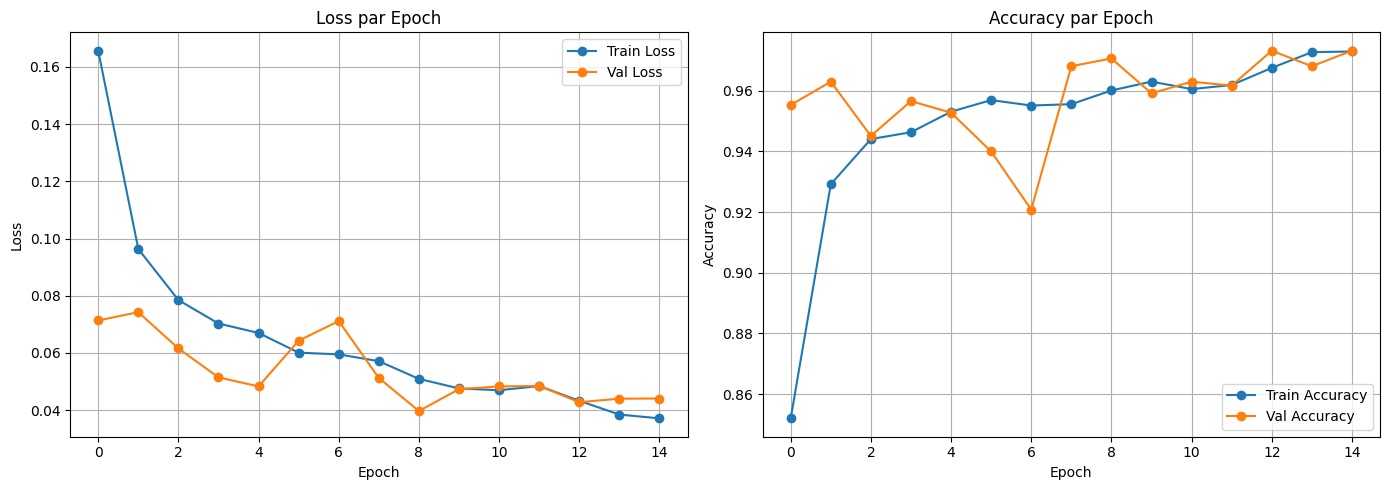

Figure sauvegardee: outputs/figures/training_curves.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss par Epoch')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy par Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../outputs/figures/training_curves.png', dpi=150)
plt.show()

print("Figure sauvegardee: outputs/figures/training_curves.png")

## 7. Evaluation sur le Test Set

In [10]:
# Charger le meilleur modele
model.load_state_dict(torch.load(best_model_path, weights_only=True))

# Evaluer sur test (la fonction validate applique deja sigmoid)
test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 1.1771
Test Accuracy: 0.7644


## Resume

### Corrections appliquees:
1. **Validation set** : Split 85/15 du train (au lieu de 16 images inutilisables)
2. **Poids de classes** : `pos_weight` dans `BCEWithLogitsLoss` pour gerer le desequilibre
3. **Architecture** : Pas de Sigmoid dans le modele (plus stable numeriquement)

### Pipeline:
- **CNN Baseline** entraine sur le dataset Chest X-Ray
- **Courbes** de loss et accuracy sauvegardees
- **Meilleur modele** sauvegarde dans `outputs/checkpoints/`

### Prochain notebook: 
Evaluation detaillee (matrice confusion, metriques)